
## CLNSIG – Dataset Bàsic (sense anotació VEP)

In [1]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC

In [2]:
df = pd.read_csv("../data/raw/clinvar_clnsig_annotated.csv")
# Crear dataset bàsic (sense columnes VEP) a partir de df annotated
vep_cols = [
    "Allele", "Consequence", "IMPACT", "SYMBOL", "Feature_type", "Feature",
    "BIOTYPE", "EXON", "INTRON", "cDNA_position", "CDS_position",
    "Protein_position", "Amino_acids", "Codons", "STRAND", "BAM_EDIT",
    "SIFT", "PolyPhen", "LoFtool", "CADD_PHRED", "CADD_RAW", "BLOSUM62"
]

df_basic = df.drop(columns=[c for c in vep_cols if c in df.columns])
df_basic.to_csv("../data/raw/clinvar_clnsig_basic.csv", index=False)

print("Annotated shape:", df.shape)
print("Basic shape:    ", df_basic.shape)
print("Columnes eliminades:", [c for c in vep_cols if c in df.columns])


Annotated shape: (60480, 47)
Basic shape:     (60480, 25)
Columnes eliminades: ['Allele', 'Consequence', 'IMPACT', 'SYMBOL', 'Feature_type', 'Feature', 'BIOTYPE', 'EXON', 'INTRON', 'cDNA_position', 'CDS_position', 'Protein_position', 'Amino_acids', 'Codons', 'STRAND', 'BAM_EDIT', 'SIFT', 'PolyPhen', 'LoFtool', 'CADD_PHRED', 'CADD_RAW', 'BLOSUM62']


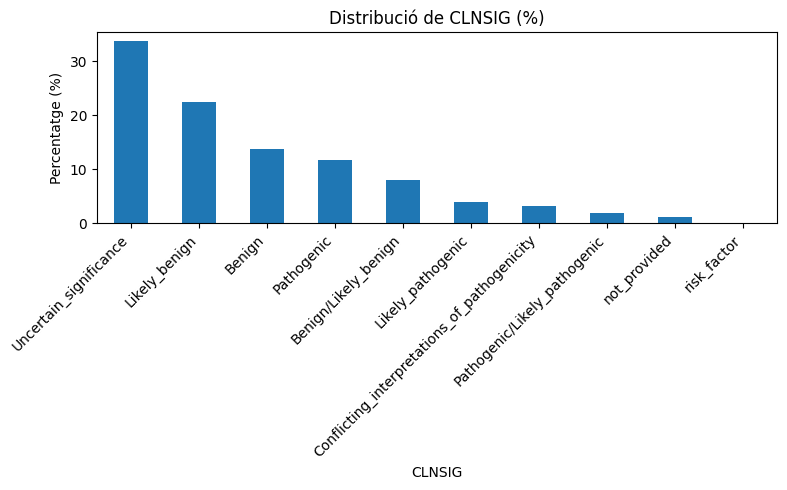

In [3]:

counts = df_basic["CLNSIG"].value_counts(dropna=False)
percent = (counts / counts.sum()) * 100
top_percent = percent.head(10)

plt.figure(figsize=(8,5))
top_percent.plot(kind="bar")

plt.title("Distribució de CLNSIG (%)")
plt.ylabel("Percentatge (%)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## Creació Classes (Bàsic)

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Valors que pertanyen a cada classe
benign_values = [
    "Benign", "Likely_benign", "Benign/Likely_benign",
    "Benign,_risk_factor", "Benign,_other", "Benign,_association",
    "Benign/Likely_benign,_risk_factor", "Benign/Likely_benign,_other",
    "Likely_benign,_risk_factor", "Likely_benign,_association"
]
vus_values = [
    "Uncertain_significance"
]
pathogenic_values = [
    "Pathogenic", "Likely_pathogenic", "Pathogenic/Likely_pathogenic",
    "Pathogenic,_risk_factor", "Pathogenic/Likely_pathogenic,_risk_factor",
    "Pathogenic,_association"
]

clnsig_map = (
    {v: 0 for v in benign_values} |
    {v: 1 for v in vus_values}    |
    {v: 2 for v in pathogenic_values}
)

# Filtrar i crear target (descartem Conflicting, not_provided, etc.)
df_multi_basic = df_basic[df_basic["CLNSIG"].isin(clnsig_map.keys())].copy()
df_multi_basic["CLNSIG_target"] = df_multi_basic["CLNSIG"].map(clnsig_map)

# Comprovació distribució
print(df_multi_basic["CLNSIG_target"].value_counts())
print(df_multi_basic["CLNSIG_target"].value_counts(normalize=True).round(3))

# Columnes a eliminar: target, CLASS antiga, i les que revelarien el resultat
cols_to_drop = ["CLNSIG", "CLNSIG_target", "CLASS"]

for col in ["CLNSIGCONF", "CLNREVSTAT"]:
    if col in df_multi_basic.columns:
        cols_to_drop.append(col)
        print(f"Eliminant columna que revela target: {col}")
    else:
        print(f"{col} no estava al dataset")

X = df_multi_basic.drop(columns=cols_to_drop)
y = df_multi_basic["CLNSIG_target"]

X_train_val_basic, X_test_basic, y_train_val_basic, y_test_basic = train_test_split(
    X, y,
    test_size=0.10,
    random_state=42,
    stratify=y
)

print(f"\nX_train_val: {X_train_val_basic.shape}")
print(f"X_test_basic:      {X_test_basic.shape}")

CLNSIG_target
0    26692
1    20358
2    10641
Name: count, dtype: int64
CLNSIG_target
0    0.463
1    0.353
2    0.184
Name: proportion, dtype: float64
CLNSIGCONF no estava al dataset
CLNREVSTAT no estava al dataset

X_train_val: (51921, 23)
X_test_basic:      (5770, 23)


In [5]:
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

df_multi_basic = df_basic[df_basic["CLNSIG"].isin(clnsig_map.keys())].copy()
df_multi_basic["CLNSIG_target"] = df_multi_basic["CLNSIG"].map(clnsig_map)


X = df_multi_basic.drop(columns=["CLNSIG", "CLNSIG_target", "CLASS"])
y = df_multi_basic["CLNSIG_target"]

X_train_val_basic, X_test_basic, y_train_val_basic, y_test_basic = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y
)

# Preprocessat 
cols_high_missing = [
    'MOTIF_SCORE_CHANGE', 'HIGH_INF_POS', 'MOTIF_POS', 'MOTIF_NAME',
    'DISTANCE', 'SSR', 'CLNSIGINCL', 'CLNDISDBINCL', 'CLNDNINCL'
]
X_train_val_basic = X_train_val_basic.drop(columns=cols_high_missing, errors="ignore")
X_test_basic      = X_test_basic.drop(columns=cols_high_missing, errors="ignore")

cols_all_missing = X_train_val_basic.columns[X_train_val_basic.isnull().mean() == 1.0].tolist()
if cols_all_missing:
    X_train_val_basic = X_train_val_basic.drop(columns=cols_all_missing)
    X_test_basic      = X_test_basic.drop(columns=cols_all_missing, errors="ignore")

num_cols = X_train_val_basic.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train_val_basic.select_dtypes(exclude=np.number).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", min_frequency=20)),
])
preprocessor_basic = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols),
])

print("X_train_val_basic shape:", X_train_val_basic.shape)
print("X_test_basic shape:", X_test_basic.shape)

X_train_val_basic shape: (51921, 14)
X_test_basic shape: (5770, 14)


## Decision Tree (Bàsic)

In [ ]:
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    StratifiedKFold, GridSearchCV, RandomizedSearchCV, train_test_split
)
from sklearn.metrics import (
    classification_report, f1_score, confusion_matrix
)
 
# Noms de les classes per als plots
CLASS_NAMES = ["Benign", "VUS", "Pathogenic"]
 
# Funció auxiliar per pintar la confusion matrix
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(title)
    plt.tight_layout()
    plt.show()
 
 
# Model base
dt = DecisionTreeClassifier(random_state=42)
 
# Pipeline preprocessament + model
pipeline_dt_basic = Pipeline(steps=[
    ("preprocess", preprocessor_basic),
    ("model", dt)
])
 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
 
# Cerca d'hiperparàmetres
param_grid = {
    "model__max_depth": [5, 10, 20, None],
    "model__min_samples_split": [2, 10, 20],
    "model__min_samples_leaf": [1, 5, 10],
    "model__class_weight": [None, "balanced"]
}
 
grid_dt_basic = GridSearchCV(
    pipeline_dt_basic,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    error_score="raise"
)
 
grid_dt_basic.fit(X_train_val_basic, y_train_val_basic)

# Resultats de la validació creuada
print(f"Millors paràmetres: {grid_dt_basic.best_params_}")
print(f"Millor CV F1 macro:  {grid_dt_basic.best_score_:.4f}")
 
best_dt_basic = grid_dt_basic.best_estimator_
y_pred_dt_basic = best_dt_basic.predict(X_test_basic)
 
print("\nClassification report al test:")
print(classification_report(y_test_basic, y_pred_dt_basic, target_names=CLASS_NAMES))
print(f"\nTest F1 macro: {f1_score(y_test_basic, y_pred_dt_basic, average='macro'):.4f}")
print(f"Confusion matrix:\n{confusion_matrix(y_test_basic, y_pred_dt_basic)}")
 
plot_confusion_matrix(
    confusion_matrix(y_test_basic, y_pred_dt_basic),
    "Confusion Matrix - Decision Tree (CLNSIG)"
)

## Random Forest (Bàsic)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# Model base
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Pipeline preprocessament + model
pipeline_rf_basic = Pipeline(steps=[
    ("preprocess", preprocessor_basic),
    ("model", rf)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cerca d'hiperparàmetres
param_dist = {
    "model__n_estimators":      [100, 200, 300],
    "model__max_depth":         [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf":  [1, 2, 5],
    "model__max_features":      ["sqrt", 0.3],
    "model__class_weight":      [None, "balanced"]
}

random_search_rf_basic = RandomizedSearchCV(
    estimator=pipeline_rf_basic,
    param_distributions=param_dist,
    n_iter=15,
    scoring="f1_macro",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    refit=True
)

random_search_rf_basic.fit(X_train_val_basic, y_train_val_basic)

# Resultats de la validació creuada
print(f"Millors paràmetres: {random_search_rf_basic.best_params_}")
print(f"Millor CV F1 macro:  {random_search_rf_basic.best_score_:.4f}")

best_rf_basic = random_search_rf_basic.best_estimator_
y_pred_rf_basic = best_rf_basic.predict(X_test_basic)

print("\nClassification report al test:")
print(classification_report(y_test_basic, y_pred_rf_basic, target_names=CLASS_NAMES))
print(f"\nTest F1 macro: {f1_score(y_test_basic, y_pred_rf_basic, average='macro'):.4f}")
print(f"Confusion matrix:\n{confusion_matrix(y_test_basic, y_pred_rf_basic)}")

plot_confusion_matrix(
    confusion_matrix(y_test_basic, y_pred_rf_basic),
    "Confusion Matrix - Random Forest (CLNSIG)"
)

## MLP (Bàsic)

In [ ]:
import warnings
from sklearn.neural_network import MLPClassifier

warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
    module=r"sklearn\.utils\.extmath"
)

# Model base
mlp = MLPClassifier(
    activation="relu",
    solver="adam",
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    tol=1e-4,
    max_iter=500,
    random_state=42
)

# Pipeline preprocessament + model
pipeline_mlp_basic = Pipeline(steps=[
    ("preprocess", preprocessor_basic),
    ("model", mlp)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cerca d'hiperparàmetres
param_dist = {
    "model__hidden_layer_sizes": [(64,), (128,), (64, 32)],
    "model__alpha":              [1e-3, 5e-3],
    "model__learning_rate_init": [1e-4, 5e-4, 1e-3],
}

random_search_mlp_basic = RandomizedSearchCV(
    estimator=pipeline_mlp_basic,
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1_macro",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=1,
    refit=True,
    error_score="raise"
)

random_search_mlp_basic.fit(X_train_val_basic, y_train_val_basic)

# Resultats de la validació creuada
print(f"Millors paràmetres: {random_search_mlp_basic.best_params_}")
print(f"Millor CV F1 macro:  {random_search_mlp_basic.best_score_:.4f}")

best_mlp_basic = random_search_mlp_basic.best_estimator_
y_pred_mlp_basic = best_mlp_basic.predict(X_test_basic)

print("\nClassification report al test:")
print(classification_report(y_test_basic, y_pred_mlp_basic, target_names=CLASS_NAMES))
print(f"\nTest F1 macro: {f1_score(y_test_basic, y_pred_mlp_basic, average='macro'):.4f}")
print(f"Confusion matrix:\n{confusion_matrix(y_test_basic, y_pred_mlp_basic)}")

plot_confusion_matrix(
    confusion_matrix(y_test_basic, y_pred_mlp_basic),
    "Confusion Matrix - MLP (CLNSIG)"
)

## Logistic Regression L2 (Bàsic)

In [ ]:
from sklearn.linear_model import LogisticRegression

# Model base
lr_l2_basic = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000, random_state=42)

# Pipeline preprocessament + model
pipeline_lr_l2_basic = Pipeline(steps=[
    ("preprocess", preprocessor_basic),
    ("model", lr_l2_basic)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cerca d'hiperparàmetres
param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1.0, 10.0],
    "model__class_weight": [None, "balanced"]
}

grid_lr_l2_basic = GridSearchCV(
    pipeline_lr_l2_basic,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    error_score="raise"
)

grid_lr_l2_basic.fit(X_train_val_basic, y_train_val_basic)

# Resultats de la validació creuada
print(f"Millors paràmetres: {grid_lr_l2_basic.best_params_}")
print(f"Millor CV F1 macro:  {grid_lr_l2_basic.best_score_:.4f}")

best_lr_l2_basic = grid_lr_l2_basic.best_estimator_
y_pred_lr_l2_basic = best_lr_l2_basic.predict(X_test_basic)

print("\nClassification report al test:")
print(classification_report(y_test_basic, y_pred_lr_l2_basic, target_names=CLASS_NAMES))
print(f"\nTest F1 macro: {f1_score(y_test_basic, y_pred_lr_l2_basic, average='macro'):.4f}")
print(f"Confusion matrix:\n{confusion_matrix(y_test_basic, y_pred_lr_l2_basic)}")

plot_confusion_matrix(
    confusion_matrix(y_test_basic, y_pred_lr_l2_basic),
    "Confusion Matrix - Logistic L2 (CLNSIG Bàsic)"
)

## Logistic Regression L1 (Bàsic)

In [ ]:
from sklearn.linear_model import LogisticRegression

# Model base
lr_l1_basic = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    max_iter=1000,
    random_state=42
)

# Pipeline preprocessament + model
pipeline_lr_l1_basic = Pipeline(steps=[
    ("preprocess", preprocessor_basic),
    ("model", lr_l1_basic)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cerca d'hiperparàmetres
param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1.0, 10.0],
    "model__class_weight": [None, "balanced"]
}

grid_lr_l1_basic = GridSearchCV(
    pipeline_lr_l1_basic,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    error_score="raise"
)

grid_lr_l1_basic.fit(X_train_val_basic, y_train_val_basic)

# Resultats de la validació creuada
print(f"Millors paràmetres: {grid_lr_l1_basic.best_params_}")
print(f"Millor CV F1 macro:  {grid_lr_l1_basic.best_score_:.4f}")

best_lr_l1_basic = grid_lr_l1_basic.best_estimator_
y_pred_lr_l1_basic = best_lr_l1_basic.predict(X_test_basic)

print("\nClassification report al test:")
print(classification_report(y_test_basic, y_pred_lr_l1_basic, target_names=CLASS_NAMES))
print(f"\nTest F1 macro: {f1_score(y_test_basic, y_pred_lr_l1_basic, average='macro'):.4f}")
print(f"Confusion matrix:\n{confusion_matrix(y_test_basic, y_pred_lr_l1_basic)}")

plot_confusion_matrix(
    confusion_matrix(y_test_basic, y_pred_lr_l1_basic),
    "Confusion Matrix - Logistic L1 (CLNSIG Bàsic)"
)

## LinearSVC (Bàsic)

In [ ]:
from sklearn.svm import LinearSVC

# Model base
svc_basic = LinearSVC(random_state=42, max_iter=2000)

# Pipeline preprocessament + model
pipeline_svc_basic = Pipeline(steps=[
    ("preprocess", preprocessor_basic),
    ("model", svc_basic)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cerca d'hiperparàmetres
param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1.0, 10.0],
    "model__class_weight": [None, "balanced"]
}

grid_svc_basic = GridSearchCV(
    pipeline_svc_basic,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    error_score="raise"
)

grid_svc_basic.fit(X_train_val_basic, y_train_val_basic)

# Resultats de la validació creuada
print(f"Millors paràmetres: {grid_svc_basic.best_params_}")
print(f"Millor CV F1 macro:  {grid_svc_basic.best_score_:.4f}")

best_svc_basic = grid_svc_basic.best_estimator_
y_pred_svc_basic = best_svc_basic.predict(X_test_basic)

print("\nClassification report al test:")
print(classification_report(y_test_basic, y_pred_svc_basic, target_names=CLASS_NAMES))
print(f"\nTest F1 macro: {f1_score(y_test_basic, y_pred_svc_basic, average='macro'):.4f}")
print(f"Confusion matrix:\n{confusion_matrix(y_test_basic, y_pred_svc_basic)}")

plot_confusion_matrix(
    confusion_matrix(y_test_basic, y_pred_svc_basic),
    "Confusion Matrix - LinearSVC (CLNSIG Bàsic)"
)

In [12]:
import pickle
import os

pkl_path = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'results_clnsig_annotated.pkl')
with open(pkl_path, 'rb') as f:
    _ann = pickle.load(f)

class _Score:
    def __init__(self, v): self.best_score_ = v

grid_dt             = _Score(_ann['dt_cv'])
random_search_rf    = _Score(_ann['rf_cv'])
random_search_mlp   = _Score(_ann['mlp_cv'])
grid_lr_l2          = _Score(_ann['l2_cv'])
grid_lr_l1          = _Score(_ann['l1_cv'])
grid_svc            = _Score(_ann['svc_cv'])
y_test              = _ann['y_test']
y_pred_dt           = _ann['y_pred_dt']
y_pred_rf           = _ann['y_pred_rf']
y_pred_mlp          = _ann['y_pred_mlp']
y_pred_lr_l2        = _ann['y_pred_lr_l2']
y_pred_lr_l1        = _ann['y_pred_lr_l1']
y_pred_svc          = _ann['y_pred_svc']
CLASS_NAMES         = _ann['CLASS_NAMES']

print('Resultats annotated carregats correctament')

Resultats annotated carregats correctament


## Comparació de Models

,Model,Dataset,CV F1 macro,Test F1 macro,Test Accuracy,F1 Benign,F1 VUS,F1 Pathogenic
0,Decision Tree,Annotated,0.8875,0.8840,0.8941,0.9364,0.8572,0.8582
1,Random Forest,Annotated,0.9043,0.9004,0.9107,0.9501,0.8760,0.8752
2,MLP,Annotated,0.8700,0.8624,0.8615,0.8877,0.8296,0.8698
3,Logistic L2,Annotated,0.8622,0.8678,0.8686,0.8981,0.8309,0.8746
4,Logistic L1,Annotated,0.8543,0.8622,0.8648,0.8970,0.8304,0.8593
5,LinearSVC,Annotated,0.8594,0.8676,0.8686,0.8992,0.8245,0.8791
6,Decision Tree,Basic,0.8706,0.8694,0.8846,0.9355,0.8466,0.8260
7,Random Forest,Basic,0.8837,0.8835,0.8995,0.9487,0.8651,0.8365
8,MLP,Basic,0.7589,0.7421,0.7286,0.7099,0.7202,0.7961
9,Logistic L2,Basic,0.8156,0.8205,0.8328,0.8799,0.8032,0.7784


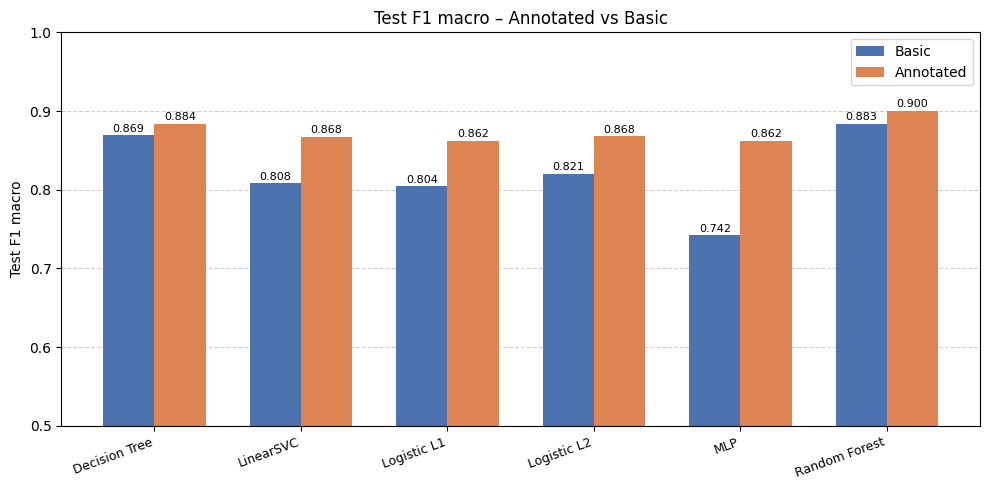

In [13]:
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

models = [
    ("Decision Tree", "Annotated", grid_dt.best_score_,                 y_test,       y_pred_dt),
    ("Random Forest", "Annotated", random_search_rf.best_score_,        y_test,       y_pred_rf),
    ("MLP",           "Annotated", random_search_mlp.best_score_,       y_test,       y_pred_mlp),
    ("Logistic L2",   "Annotated", grid_lr_l2.best_score_,              y_test,       y_pred_lr_l2),
    ("Logistic L1",   "Annotated", grid_lr_l1.best_score_,              y_test,       y_pred_lr_l1),
    ("LinearSVC",     "Annotated", grid_svc.best_score_,                y_test,       y_pred_svc),
    ("Decision Tree", "Basic",     grid_dt_basic.best_score_,           y_test_basic, y_pred_dt_basic),
    ("Random Forest", "Basic",     random_search_rf_basic.best_score_,  y_test_basic, y_pred_rf_basic),
    ("MLP",           "Basic",     random_search_mlp_basic.best_score_, y_test_basic, y_pred_mlp_basic),
    ("Logistic L2",   "Basic",     grid_lr_l2_basic.best_score_,        y_test_basic, y_pred_lr_l2_basic),
    ("Logistic L1",   "Basic",     grid_lr_l1_basic.best_score_,        y_test_basic, y_pred_lr_l1_basic),
    ("LinearSVC",     "Basic",     grid_svc_basic.best_score_,          y_test_basic, y_pred_svc_basic),
]

rows = []
for name, dataset, cv_f1, y_true, y_pred in models:
    rep = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)
    rows.append({
        "Model":         name,
        "Dataset":       dataset,
        "CV F1 macro":   round(cv_f1, 4),
        "Test F1 macro": round(rep["macro avg"]["f1-score"], 4),
        "Test Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "F1 Benign":     round(rep["Benign"]["f1-score"], 4),
        "F1 VUS":        round(rep["VUS"]["f1-score"], 4),
        "F1 Pathogenic": round(rep["Pathogenic"]["f1-score"], 4),
    })

df_results = pd.DataFrame(rows)
display(df_results)

pivot = df_results.pivot(index="Model", columns="Dataset", values="Test F1 macro")

model_names = pivot.index.tolist()
x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, pivot["Basic"],     width, label="Basic",     color="#4C72B0")
ax.bar(x + width/2, pivot["Annotated"], width, label="Annotated", color="#DD8452")

for i, (b, a) in enumerate(zip(pivot["Basic"], pivot["Annotated"])):
    ax.text(i - width/2, b + 0.002, f"{b:.3f}", ha="center", va="bottom", fontsize=8)
    ax.text(i + width/2, a + 0.002, f"{a:.3f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=20, ha="right", fontsize=9)
ax.set_ylim(0.50, 1.00)
ax.set_ylabel("Test F1 macro")
ax.set_title("Test F1 macro – Annotated vs Basic")
ax.legend()
ax.yaxis.grid(True, linestyle="--", alpha=0.6)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### SHAP – Dataset Bàsic

In [14]:
import shap
import scipy.sparse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree


def normalize_sv_list(sv_raw):
    """Retorna llista de arrays 2D (n_samples, n_features) per classe."""
    if isinstance(sv_raw, list):
        return [np.array(sv, dtype=np.float64) for sv in sv_raw]
    sv_raw = np.array(sv_raw, dtype=np.float64)
    if sv_raw.ndim == 3:
        return [sv_raw[:, :, c] for c in range(sv_raw.shape[2])]
    return [sv_raw]


def plot_shap_multiclass(sv_list, feature_names, model_title,
                         class_names=CLASS_NAMES, top_k=15):
    clean = [f.replace("num__", "").replace("cat__", "") for f in feature_names]

    global_abs = np.mean([np.abs(sv).mean(axis=0) for sv in sv_list], axis=0)
    global_df = pd.DataFrame({"feature": clean, "importance": global_abs})
    top_global = global_df.nlargest(top_k, "importance").sort_values("importance")

    plt.figure(figsize=(10, 7))
    plt.barh(top_global["feature"], top_global["importance"], color="#4C72B0")
    plt.title(f"{model_title} – Importància global SHAP (Top {top_k})")
    plt.xlabel("Mean |SHAP value|")
    plt.tight_layout()
    plt.show()

    top_features = top_global["feature"].tolist()
    fig, axes = plt.subplots(1, len(class_names),
                             figsize=(6 * len(class_names), 7), sharey=True)
    if len(class_names) == 1:
        axes = [axes]
    for i, (sv, cn) in enumerate(zip(sv_list, class_names)):
        mean_signed = sv.mean(axis=0)
        sdf = pd.DataFrame({"feature": clean, "shap": mean_signed})
        sdf = (sdf[sdf["feature"].isin(top_features)]
               .drop_duplicates("feature")
               .set_index("feature")
               .reindex(top_features)
               .sort_values("shap"))
        colors = ["#C44E52" if x < 0 else "#4C72B0" for x in sdf["shap"]]
        axes[i].barh(sdf.index, sdf["shap"], color=colors)
        axes[i].axvline(0, color="black", linewidth=1)
        axes[i].set_title(f"Classe: {cn}")
        axes[i].set_xlabel("Mean SHAP value")
    fig.suptitle(f"{model_title} – SHAP signat per classe", fontsize=13)
    plt.tight_layout()
    plt.show()


def get_normalized_shap_multiclass(sv_list, feature_names):
    global_abs = np.mean([np.abs(sv).mean(axis=0) for sv in sv_list], axis=0)
    total = global_abs.sum() or 1
    clean = [f.replace("num__", "").replace("cat__", "") for f in feature_names]
    return pd.Series(global_abs / total, index=clean)


def plot_cross_model_shap(meta_df, model_cols, title_suffix):
    top15 = meta_df.sort_values("mean_rank").head(15)
    print(f"Top 15 features més consistents entre models ({title_suffix}):")
    display(top15[model_cols + ["mean_across_models", "mean_rank"]].round(4))

    plt.figure(figsize=(9, 8))
    sns.heatmap(top15[model_cols], annot=True, fmt=".3f",
                cmap="YlOrRd", linewidths=0.5)
    plt.title(f"Importància SHAP normalitzada – Top 15 ({title_suffix})")
    plt.tight_layout()
    plt.show()

    top15_r = meta_df.sort_values("mean_rank").head(15).copy()
    top15_r["feature"] = top15_r.index
    plt.figure(figsize=(10, 7))
    plt.barh(top15_r["feature"][::-1], top15_r["mean_rank"][::-1], color="#4C72B0")
    plt.title(f"Ranking mitjà entre models – {title_suffix}")
    plt.xlabel("Mean rank")
    plt.tight_layout()
    plt.show()


def shorten(name, n=35):
    name = name.replace("num__", "").replace("cat__", "")
    return name[:n] + "..." if len(name) > n else name


/Users/eliag/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Classes: 3, forma: (5770, 758)


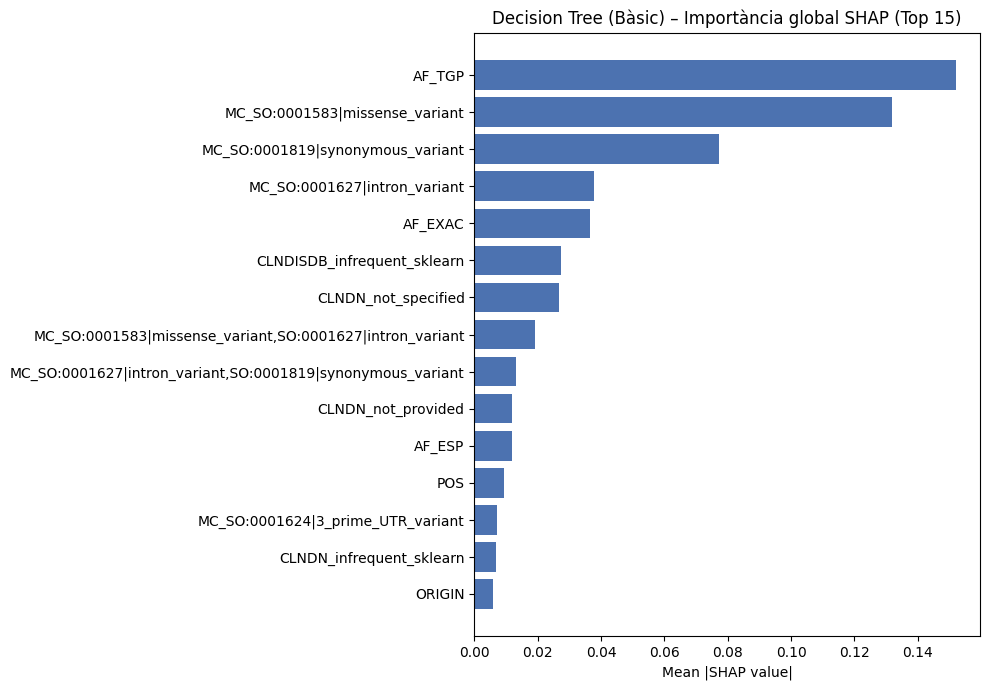

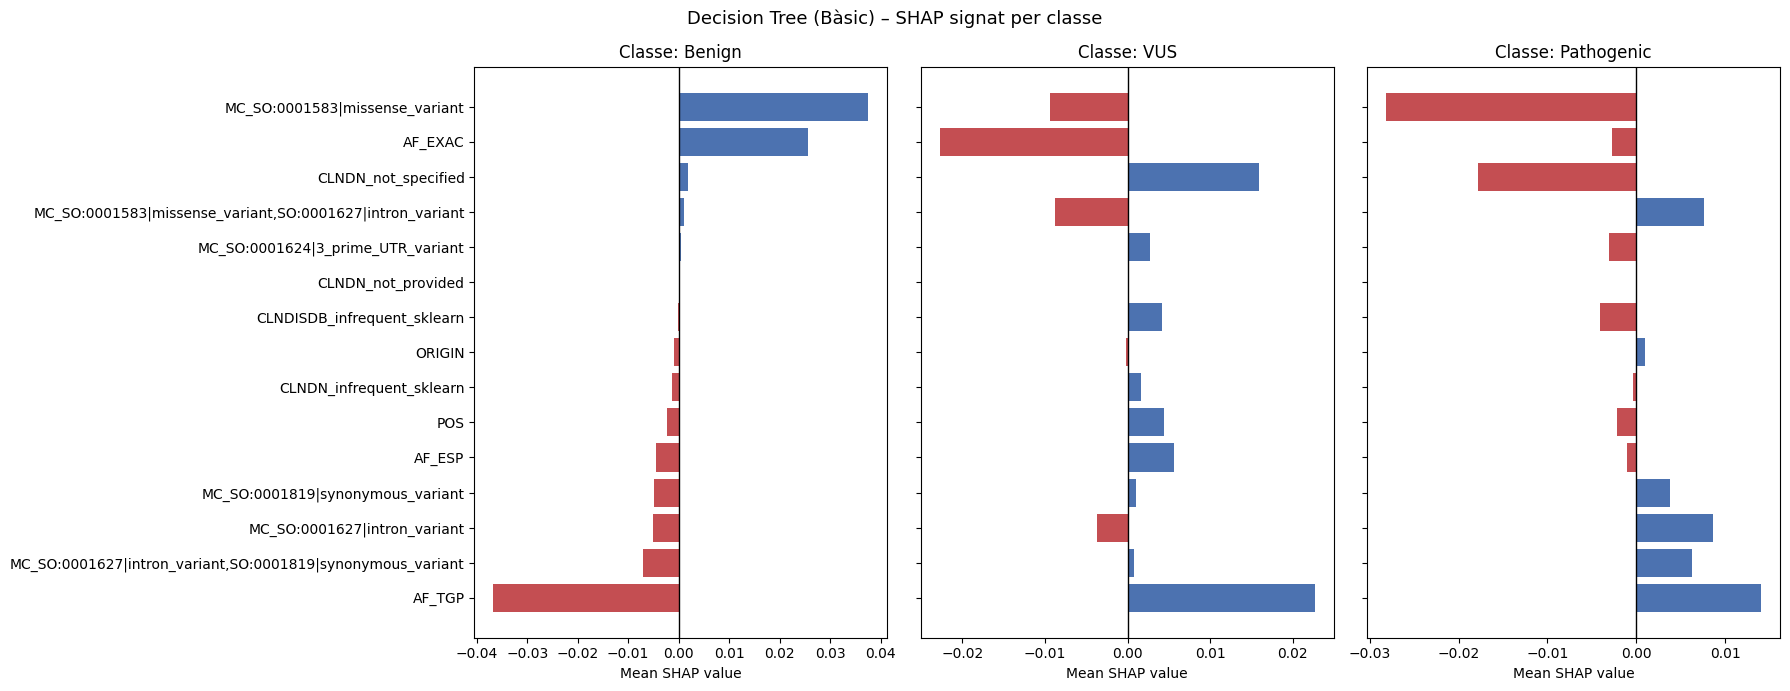

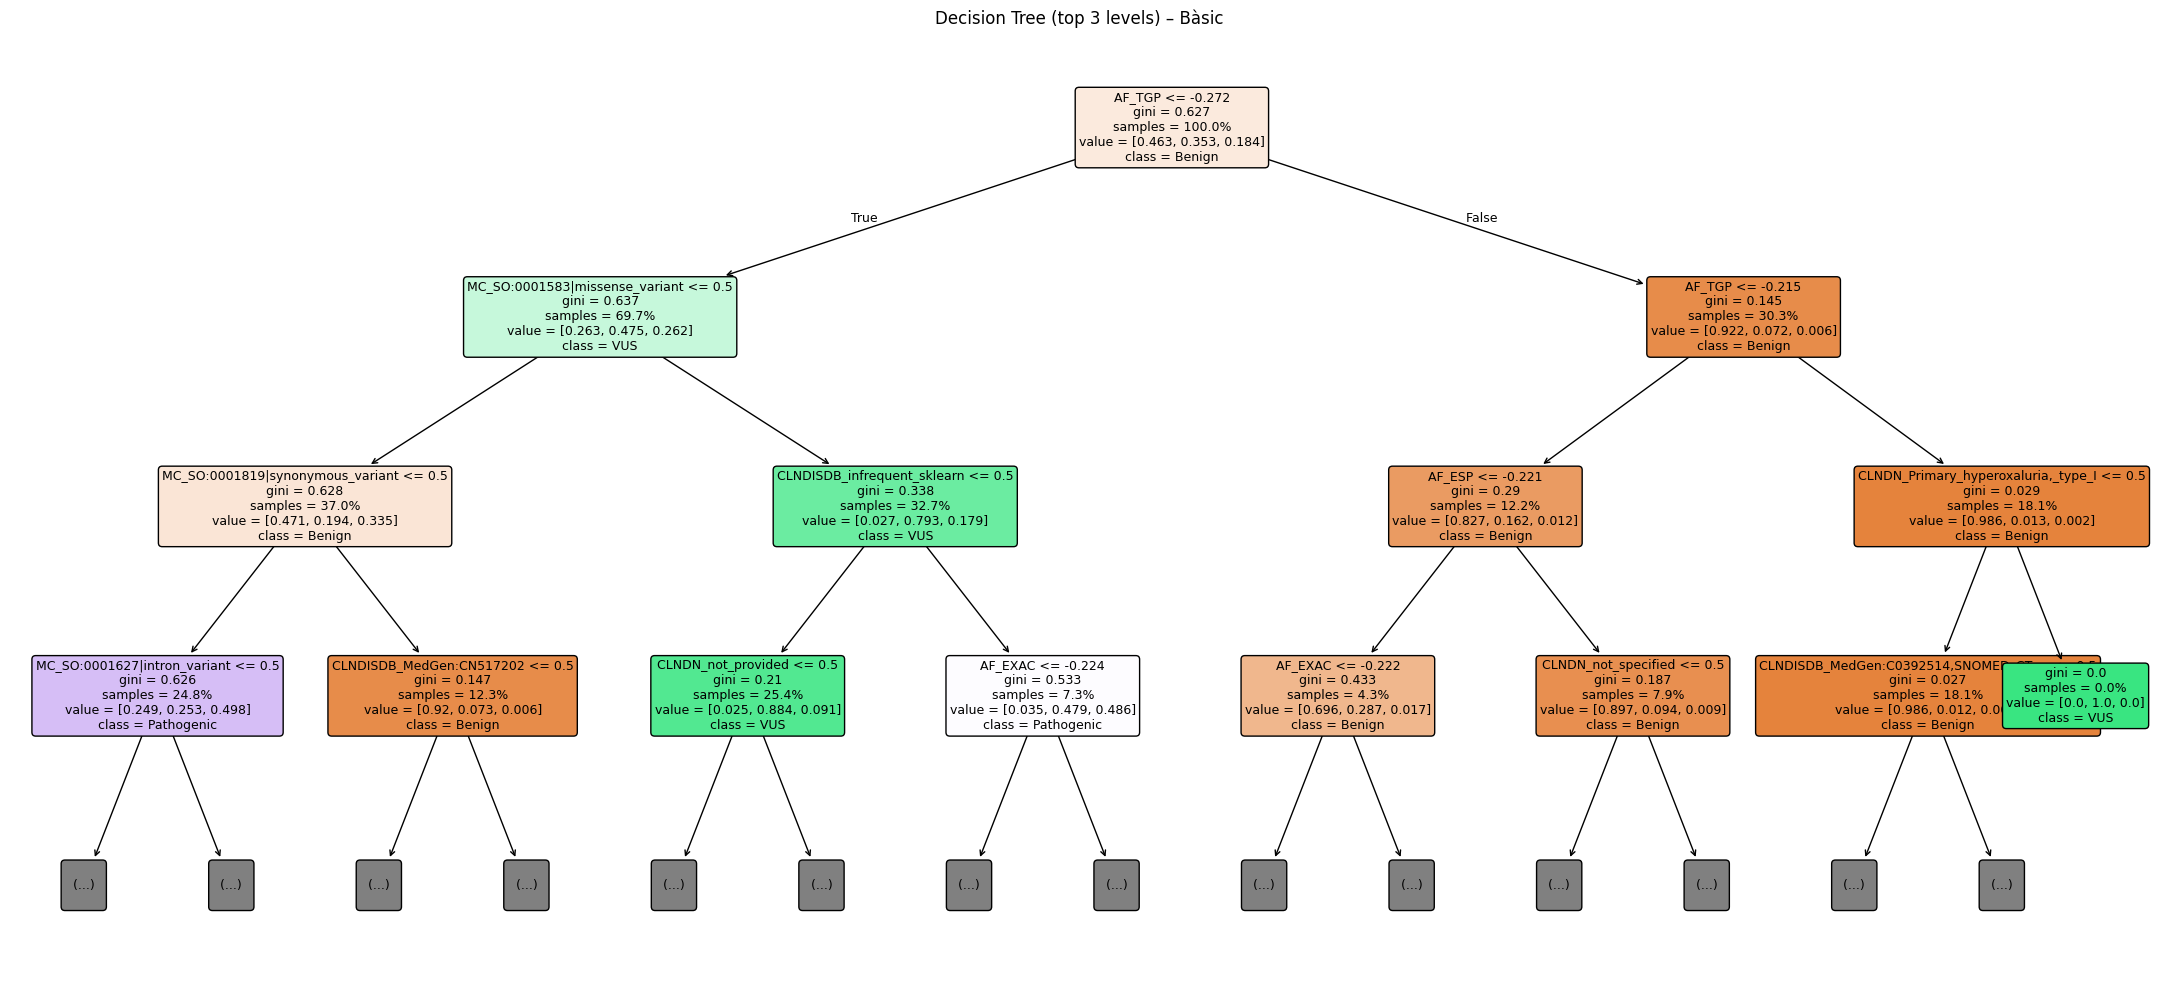

In [15]:

import scipy.sparse
import shap

X_test_tr_dt_b = best_dt_basic.named_steps["preprocess"].transform(X_test_basic)
if scipy.sparse.issparse(X_test_tr_dt_b):
    X_test_tr_dt_b = X_test_tr_dt_b.toarray().astype(np.float64)
else:
    X_test_tr_dt_b = np.array(X_test_tr_dt_b, dtype=np.float64)

feature_names_dt_b = best_dt_basic.named_steps["preprocess"].get_feature_names_out()
explainer_dt_b = shap.TreeExplainer(best_dt_basic.named_steps["model"])
shap_values_dt_b_raw = explainer_dt_b.shap_values(X_test_tr_dt_b)
sv_list_dt_b = normalize_sv_list(shap_values_dt_b_raw)

print(f"Classes: {len(sv_list_dt_b)}, forma: {sv_list_dt_b[0].shape}")
plot_shap_multiclass(sv_list_dt_b, feature_names_dt_b, "Decision Tree (Bàsic)")

plt.figure(figsize=(22, 10))
plot_tree(
    best_dt_basic.named_steps["model"],
    feature_names=[shorten(f) for f in feature_names_dt_b],
    class_names=CLASS_NAMES,
    filled=True, rounded=True, max_depth=3,
    fontsize=9, impurity=True, proportion=True
)
plt.title("Decision Tree (top 3 levels) – Bàsic")
plt.tight_layout()
plt.show()

Classes: 3, forma: (5770, 758)


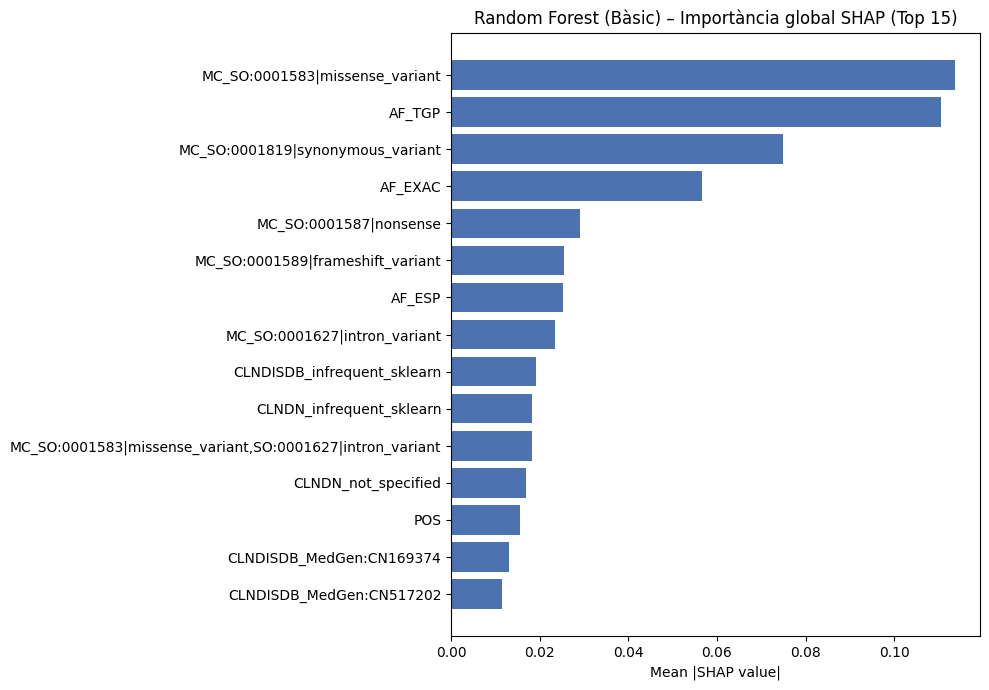

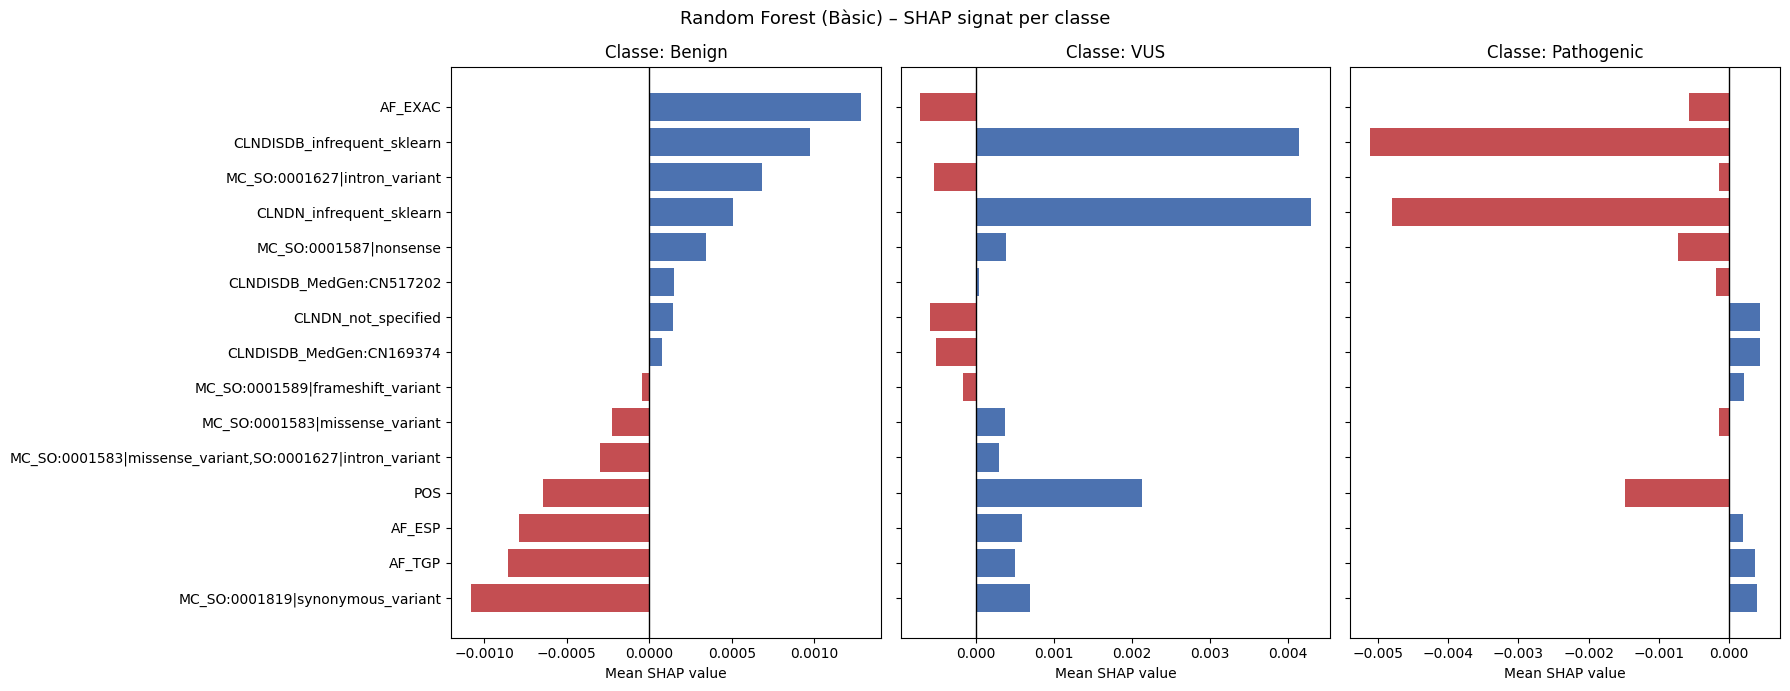

In [16]:
X_test_tr_rf_b = best_rf_basic.named_steps["preprocess"].transform(X_test_basic)
if scipy.sparse.issparse(X_test_tr_rf_b):
    X_test_tr_rf_b = X_test_tr_rf_b.toarray().astype(np.float64)
else:
    X_test_tr_rf_b = np.array(X_test_tr_rf_b, dtype=np.float64)

feature_names_rf_b = best_rf_basic.named_steps["preprocess"].get_feature_names_out()
explainer_rf_b = shap.TreeExplainer(best_rf_basic.named_steps["model"])
shap_values_rf_b_raw = explainer_rf_b.shap_values(
    X_test_tr_rf_b, approximate=True, check_additivity=False
)
sv_list_rf_b = normalize_sv_list(shap_values_rf_b_raw)

print(f"Classes: {len(sv_list_rf_b)}, forma: {sv_list_rf_b[0].shape}")
plot_shap_multiclass(sv_list_rf_b, feature_names_rf_b, "Random Forest (Bàsic)")

/Users/eliag/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/eliag/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/eliag/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sample_weight


X_test_tr_mlp_b shape: (5770, 758)


  0%|          | 0/5770 [00:00<?, ?it/s]/Users/eliag/Library/Python/3.9/lib/python/site-packages/shap/explainers/_kernel.py:706: RuntimeWarning: divide by zero encountered in matmul
  w = np.linalg.solve(X.T @ WX, WX.T @ y)
/Users/eliag/Library/Python/3.9/lib/python/site-packages/shap/explainers/_kernel.py:706: RuntimeWarning: overflow encountered in matmul
  w = np.linalg.solve(X.T @ WX, WX.T @ y)
/Users/eliag/Library/Python/3.9/lib/python/site-packages/shap/explainers/_kernel.py:706: RuntimeWarning: invalid value encountered in matmul
  w = np.linalg.solve(X.T @ WX, WX.T @ y)
/Users/eliag/Library/Python/3.9/lib/python/site-packages/shap/explainers/_kernel.py:706: RuntimeWarning: divide by zero encountered in matmul
  w = np.linalg.solve(X.T @ WX, WX.T @ y)
/Users/eliag/Library/Python/3.9/lib/python/site-packages/shap/explainers/_kernel.py:706: RuntimeWarning: overflow encountered in matmul
  w = np.linalg.solve(X.T @ WX, WX.T @ y)
/Users/eliag/Library/Python/3.9/lib/python/site-packa

Classes: 3, forma: (5770, 758)


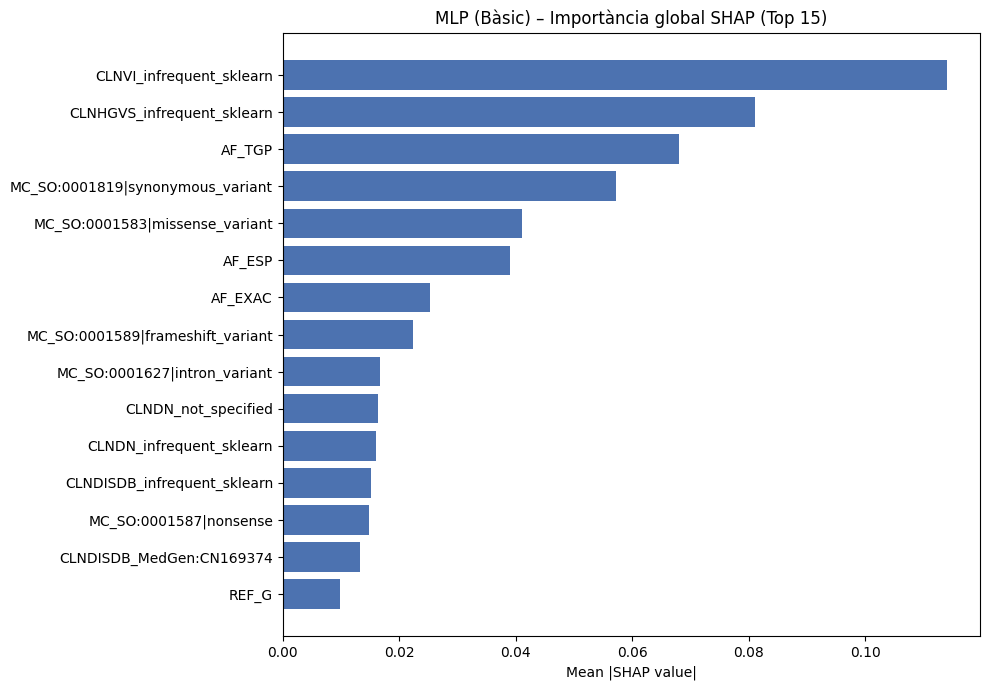

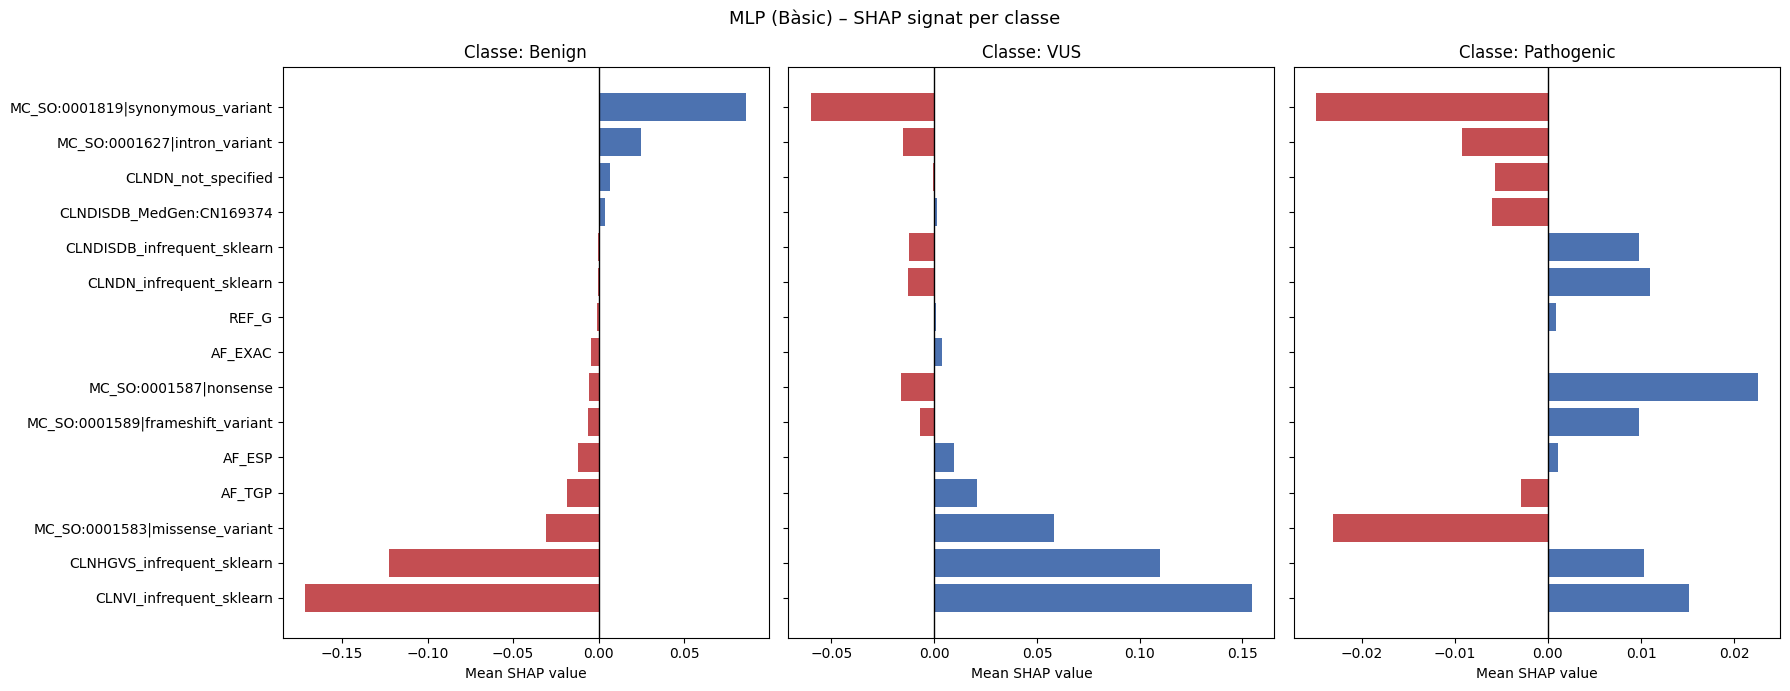

In [17]:
X_test_tr_mlp_b = best_mlp_basic.named_steps["preprocess"].transform(X_test_basic)
if scipy.sparse.issparse(X_test_tr_mlp_b):
    X_test_tr_mlp_b = X_test_tr_mlp_b.toarray().astype(np.float64)
else:
    X_test_tr_mlp_b = np.array(X_test_tr_mlp_b, dtype=np.float64)

X_train_tr_mlp_b = best_mlp_basic.named_steps["preprocess"].transform(X_train_val_basic)
if scipy.sparse.issparse(X_train_tr_mlp_b):
    X_train_tr_mlp_b = X_train_tr_mlp_b.toarray().astype(np.float64)
else:
    X_train_tr_mlp_b = np.array(X_train_tr_mlp_b, dtype=np.float64)

feature_names_mlp_b = best_mlp_basic.named_steps["preprocess"].get_feature_names_out()
mlp_model_b = best_mlp_basic.named_steps["model"]

background_mlp_b = shap.kmeans(X_train_tr_mlp_b, 30)
print("X_test_tr_mlp_b shape:", X_test_tr_mlp_b.shape)

explainer_mlp_b = shap.KernelExplainer(mlp_model_b.predict_proba, background_mlp_b)
shap_values_mlp_b_raw = explainer_mlp_b.shap_values(X_test_tr_mlp_b, nsamples=100)
sv_list_mlp_b = normalize_sv_list(shap_values_mlp_b_raw)

print(f"Classes: {len(sv_list_mlp_b)}, forma: {sv_list_mlp_b[0].shape}")
plot_shap_multiclass(sv_list_mlp_b, feature_names_mlp_b, "MLP (Bàsic)")

Classes: 3, forma: (5770, 758)


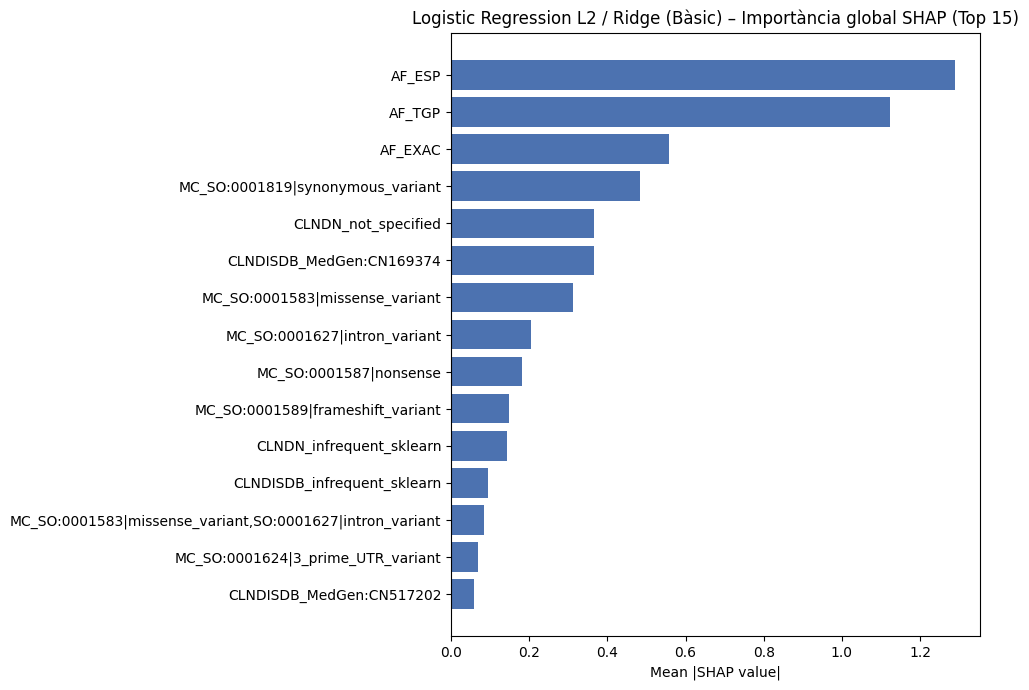

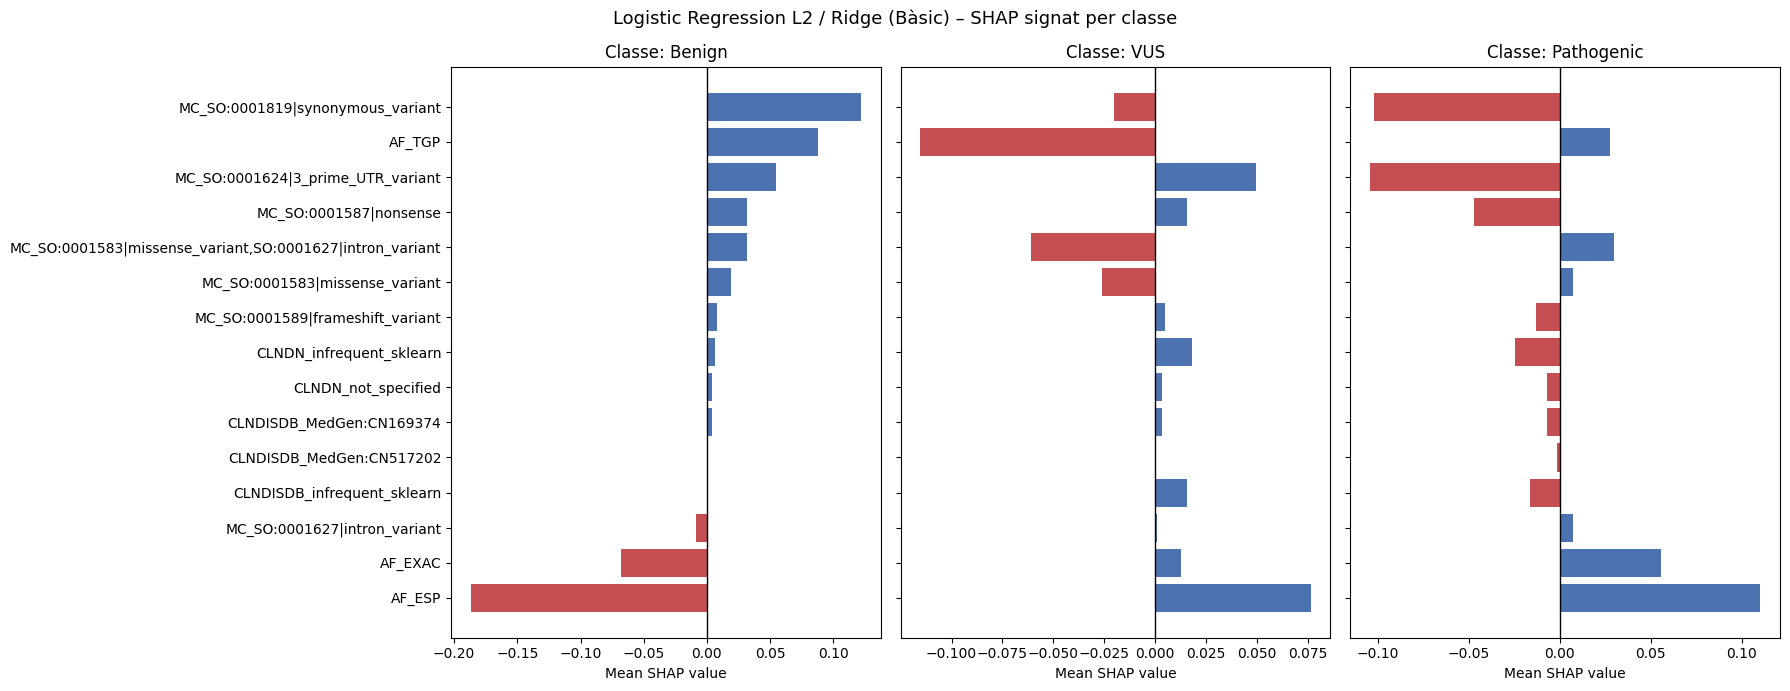

In [18]:
X_test_tr_lr_l2_b = best_lr_l2_basic.named_steps["preprocess"].transform(X_test_basic)
if scipy.sparse.issparse(X_test_tr_lr_l2_b):
    X_test_tr_lr_l2_b = X_test_tr_lr_l2_b.toarray().astype(np.float64)
else:
    X_test_tr_lr_l2_b = np.array(X_test_tr_lr_l2_b, dtype=np.float64)

feature_names_lr_l2_b = best_lr_l2_basic.named_steps["preprocess"].get_feature_names_out()
explainer_lr_l2_b = shap.LinearExplainer(best_lr_l2_basic.named_steps["model"], X_test_tr_lr_l2_b)
shap_values_lr_l2_b_raw = explainer_lr_l2_b.shap_values(X_test_tr_lr_l2_b)
sv_list_lr_l2_b = normalize_sv_list(shap_values_lr_l2_b_raw)

print(f"Classes: {len(sv_list_lr_l2_b)}, forma: {sv_list_lr_l2_b[0].shape}")
plot_shap_multiclass(sv_list_lr_l2_b, feature_names_lr_l2_b, "Logistic Regression L2 / Ridge (Bàsic)")

Classes: 3, forma: (5770, 758)


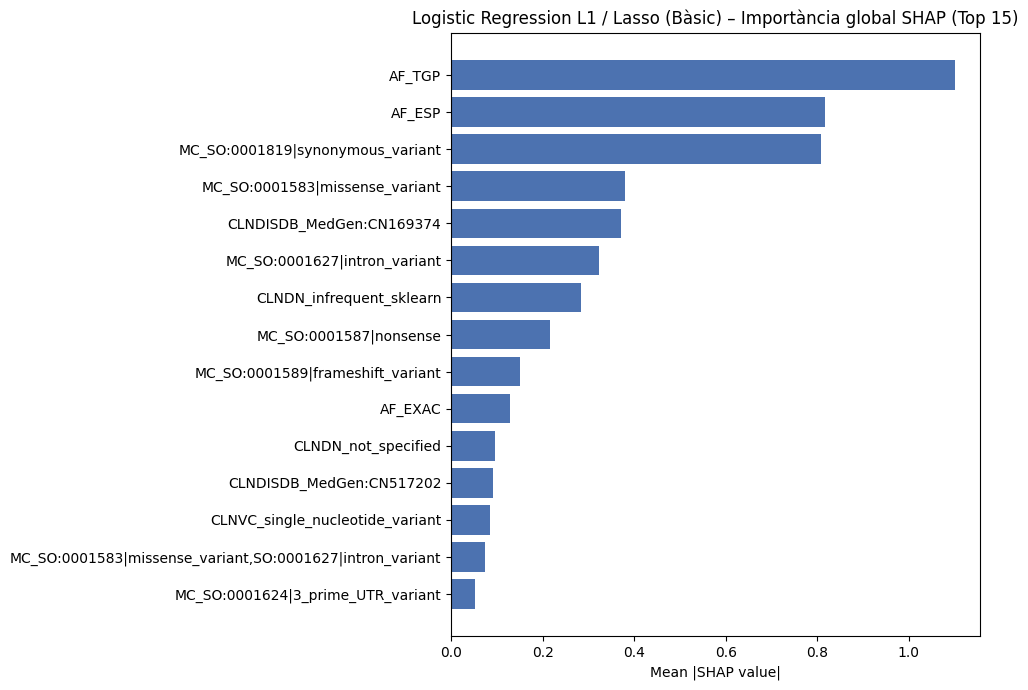

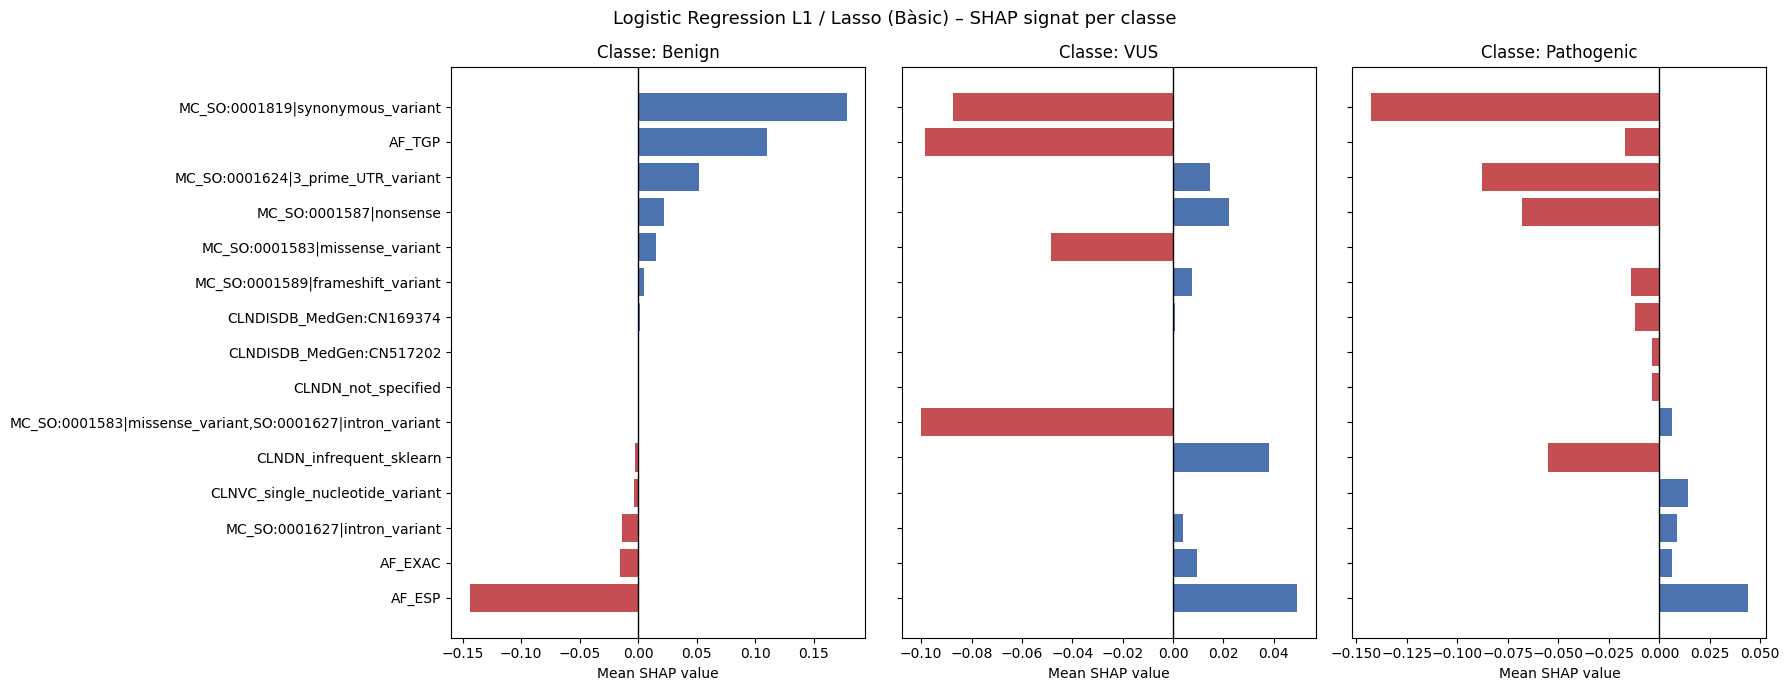

In [19]:
X_test_tr_lr_l1_b = best_lr_l1_basic.named_steps["preprocess"].transform(X_test_basic)
if scipy.sparse.issparse(X_test_tr_lr_l1_b):
    X_test_tr_lr_l1_b = X_test_tr_lr_l1_b.toarray().astype(np.float64)
else:
    X_test_tr_lr_l1_b = np.array(X_test_tr_lr_l1_b, dtype=np.float64)

feature_names_lr_l1_b = best_lr_l1_basic.named_steps["preprocess"].get_feature_names_out()
explainer_lr_l1_b = shap.LinearExplainer(best_lr_l1_basic.named_steps["model"], X_test_tr_lr_l1_b)
shap_values_lr_l1_b_raw = explainer_lr_l1_b.shap_values(X_test_tr_lr_l1_b)
sv_list_lr_l1_b = normalize_sv_list(shap_values_lr_l1_b_raw)

print(f"Classes: {len(sv_list_lr_l1_b)}, forma: {sv_list_lr_l1_b[0].shape}")
plot_shap_multiclass(sv_list_lr_l1_b, feature_names_lr_l1_b, "Logistic Regression L1 / Lasso (Bàsic)")

Classes: 3, forma: (5770, 758)


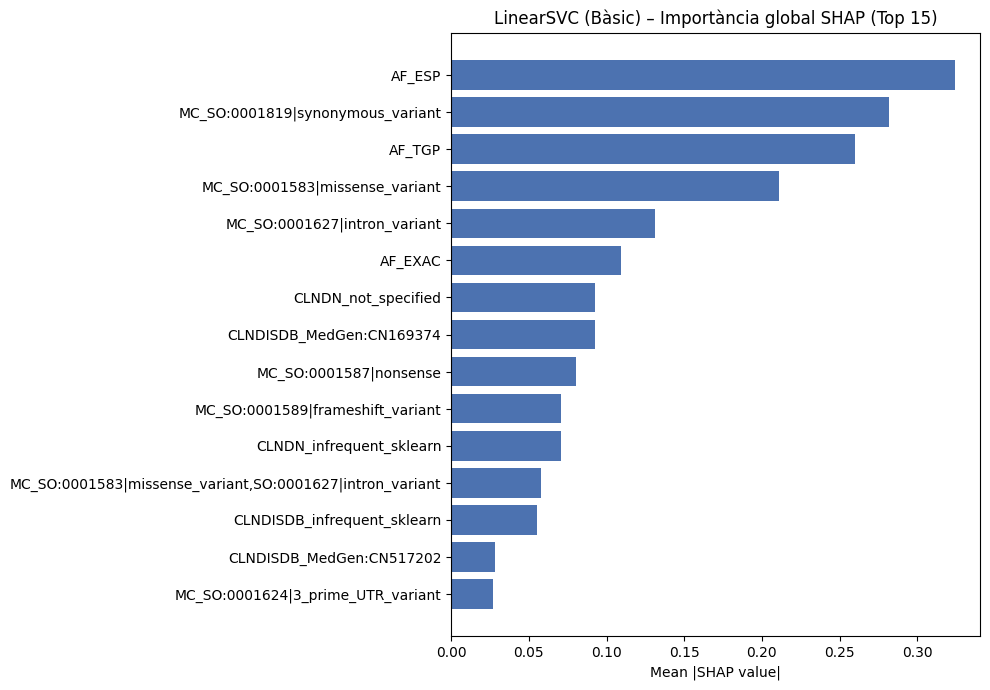

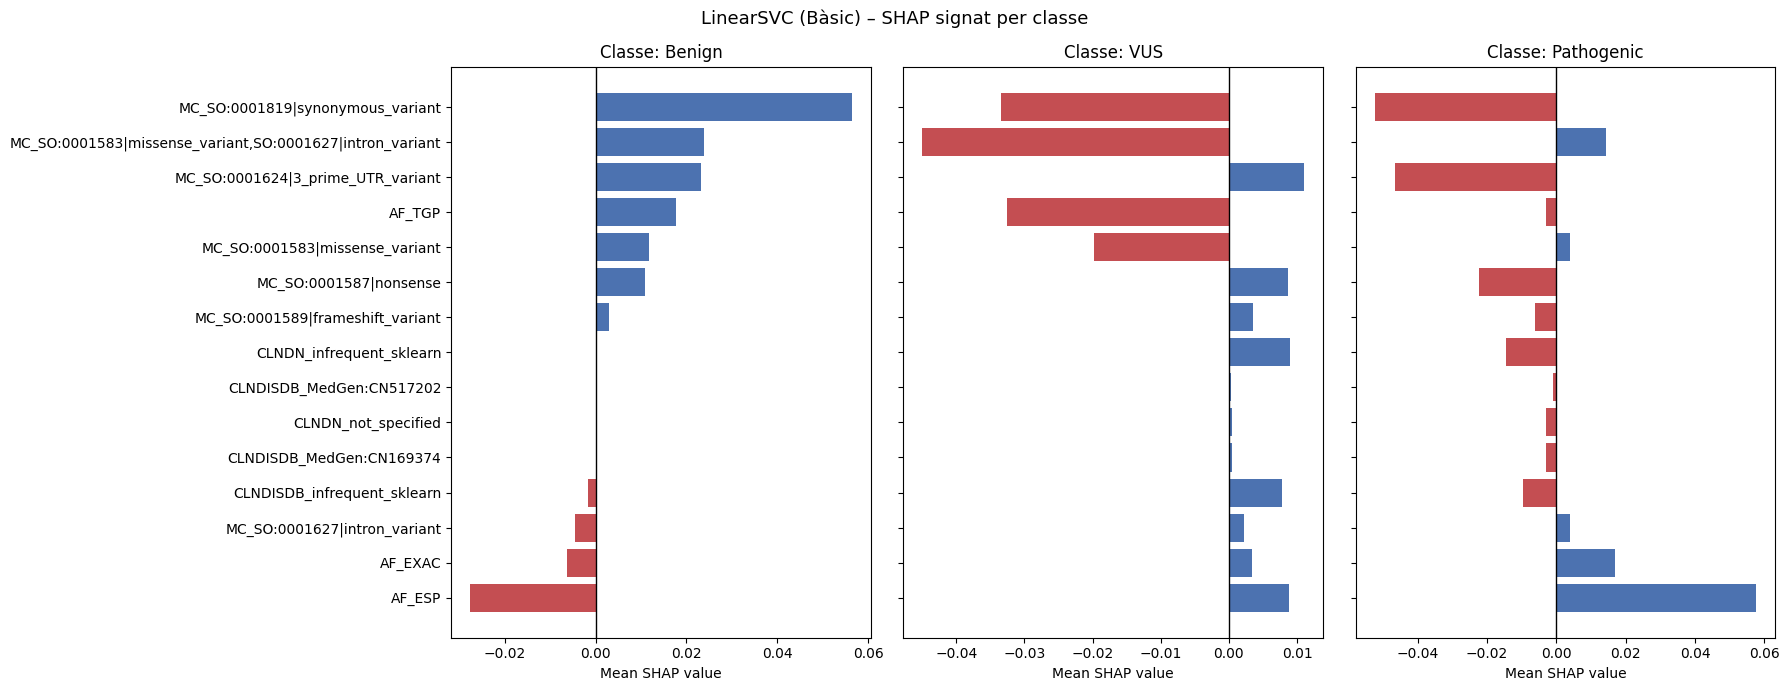

In [20]:
X_test_tr_svc_b = best_svc_basic.named_steps["preprocess"].transform(X_test_basic)
if scipy.sparse.issparse(X_test_tr_svc_b):
    X_test_tr_svc_b = X_test_tr_svc_b.toarray().astype(np.float64)
else:
    X_test_tr_svc_b = np.array(X_test_tr_svc_b, dtype=np.float64)

feature_names_svc_b = best_svc_basic.named_steps["preprocess"].get_feature_names_out()
explainer_svc_b = shap.LinearExplainer(best_svc_basic.named_steps["model"], X_test_tr_svc_b)
shap_values_svc_b_raw = explainer_svc_b.shap_values(X_test_tr_svc_b)
sv_list_svc_b = normalize_sv_list(shap_values_svc_b_raw)

print(f"Classes: {len(sv_list_svc_b)}, forma: {sv_list_svc_b[0].shape}")
plot_shap_multiclass(sv_list_svc_b, feature_names_svc_b, "LinearSVC (Bàsic)")

Top 15 features més consistents entre models (Bàsic):


,Decision Tree,Random Forest,MLP,Logistic L2,Logistic L1,Linear SVC,mean_across_models,mean_rank
AF_TGP,0.2429,0.1563,0.0978,0.1791,0.2099,0.1147,0.1668,2.0000
MC_SO:0001819|synonymous_variant,0.1234,0.1061,0.0823,0.0771,0.1542,0.1242,0.1112,3.1667
MC_SO:0001583|missense_variant,0.2109,0.1608,0.0590,0.0495,0.0726,0.0932,0.1077,3.8333
AF_ESP,0.0189,0.0358,0.0562,0.2054,0.1557,0.1430,0.1025,4.6667
AF_EXAC,0.0580,0.0800,0.0364,0.0888,0.0244,0.0483,0.0560,5.8333
MC_SO:0001627|intron_variant,0.0601,0.0330,0.0239,0.0323,0.0615,0.0578,0.0448,6.6667
CLNDN_not_specified,0.0429,0.0238,0.0235,0.0581,0.0185,0.0407,0.0346,8.6667
CLNDN_infrequent_sklearn,0.0107,0.0259,0.0231,0.0229,0.0541,0.0311,0.0280,10.6667
CLNDISDB_infrequent_sklearn,0.0435,0.0271,0.0218,0.0151,0.0068,0.0244,0.0231,11.6667
MC_SO:0001587|nonsense,0.0016,0.0412,0.0213,0.0288,0.0410,0.0353,0.0282,12.1667


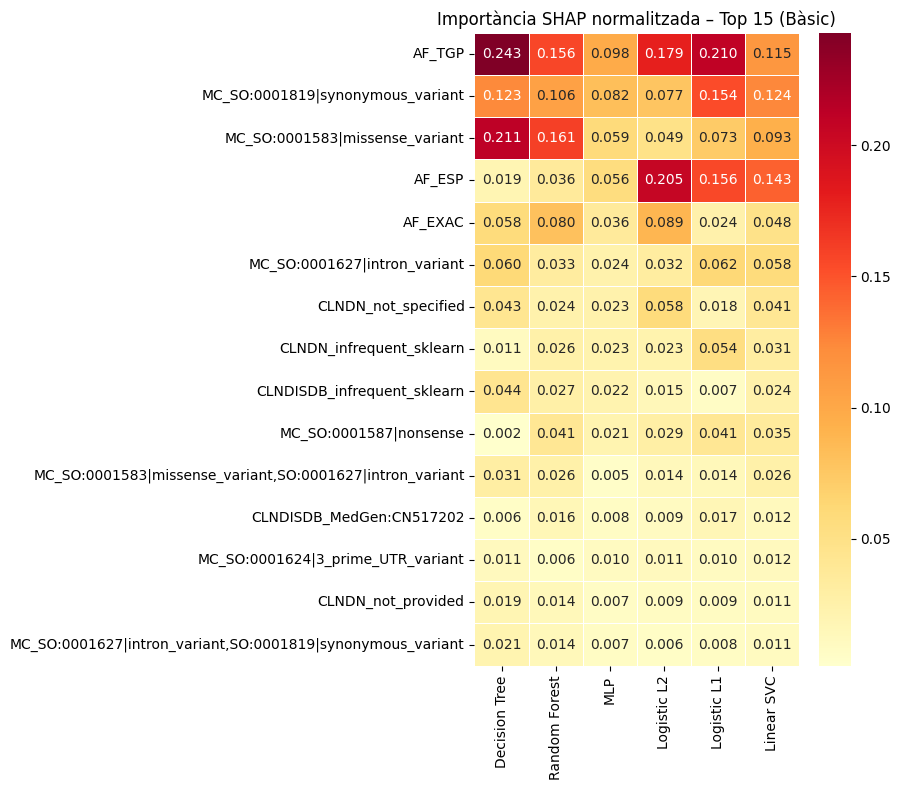

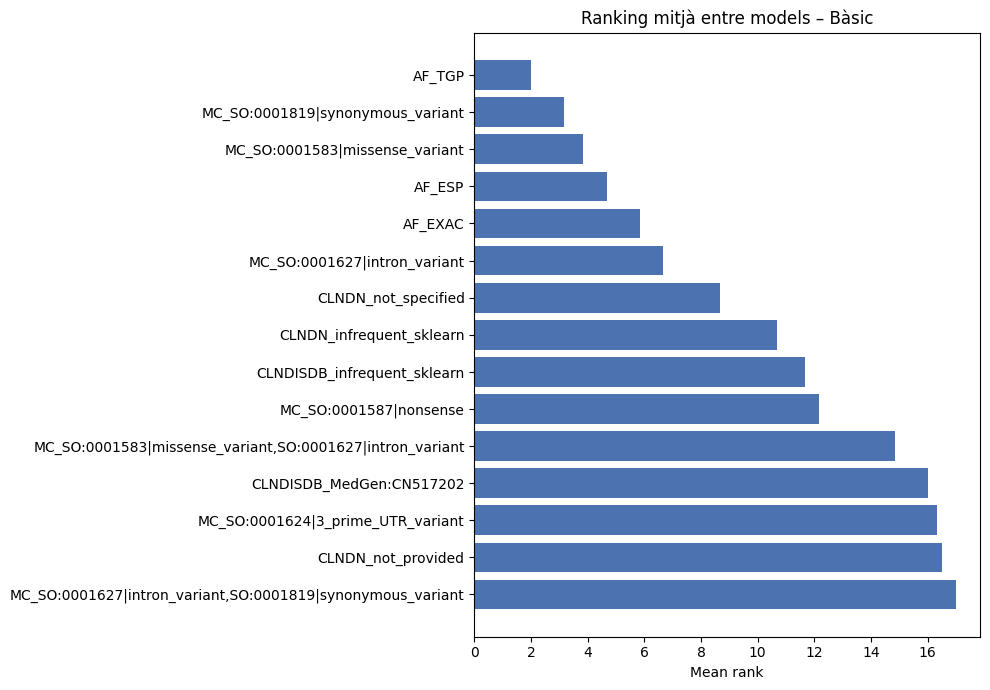

In [21]:
importance_dt_b    = get_normalized_shap_multiclass(sv_list_dt_b,    feature_names_dt_b)
importance_rf_b    = get_normalized_shap_multiclass(sv_list_rf_b,    feature_names_rf_b)
importance_mlp_b   = get_normalized_shap_multiclass(sv_list_mlp_b,   feature_names_mlp_b)
importance_lr_l2_b = get_normalized_shap_multiclass(sv_list_lr_l2_b, feature_names_lr_l2_b)
importance_lr_l1_b = get_normalized_shap_multiclass(sv_list_lr_l1_b, feature_names_lr_l1_b)
importance_svc_b   = get_normalized_shap_multiclass(sv_list_svc_b,   feature_names_svc_b)

meta_basic = pd.DataFrame({
    "Decision Tree": importance_dt_b,
    "Random Forest": importance_rf_b,
    "MLP":           importance_mlp_b,
    "Logistic L2":   importance_lr_l2_b,
    "Logistic L1":   importance_lr_l1_b,
    "Linear SVC":    importance_svc_b,
}).fillna(0)

model_cols_b = ["Decision Tree", "Random Forest", "MLP", "Logistic L2", "Logistic L1", "Linear SVC"]
meta_basic["mean_across_models"] = meta_basic[model_cols_b].mean(axis=1)
for col in model_cols_b:
    meta_basic[f"rank_{col}"] = meta_basic[col].rank(ascending=False).astype(int)
meta_basic["mean_rank"] = meta_basic[[f"rank_{col}" for col in model_cols_b]].mean(axis=1)

plot_cross_model_shap(meta_basic, model_cols_b, "Bàsic")